# TurboTax Homepage Experience Personalization

## Section 0 — Overview

### Problem framing
Millions of visitors abandon TurboTax before authenticating. We want to predict which of **7 homepage experiences** maximizes the probability of **first-time authentication** for each session, and quantify the **predicted uplift** vs. the experience actually shown.

### ML formulation
- **Outcome:** `authenticated` (binary) — did the visitor first-auth in the **same session** as the homepage impression, at or after the homepage event?
- **Treatment:** `experience_id` (1–7), included as a categorical feature in logistic regression
- **Model:** `P(auth | X, experience)` where X = session/visitor/cookie features built from pre-homepage clickstream

### Decision point
One row per **homepage session** where `experience_id` is populated. Clickstream is truncated **before first auth** per visitor; features use only events **before** the homepage timestamp (no leakage).

### Assumptions
1. Experience assignment is approximately ignorable given features (partially true in synthetic data; weak in real observational logs)
2. Session features capture enough visitor intent for counterfactual extrapolation
3. Only first auth in the homepage session (at or after the impression) counts as success

### Limitations
- Only one experience observed per session — no ground-truth counterfactual outcomes
- Logistic regression may underfit cookie/URL interactions
- Offline uplift is model-based, not causal
- URL featurization is intentionally shallow

### Next steps (not implemented)
- IPS / doubly-robust offline policy evaluation
- T-learner / X-learner uplift models
- Gradient boosting, calibration tuning
- Online A/B validation in production

## Section 1 — Setup

In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import RANDOM_STATE
from src.data_loading import load_tables

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

first_auth_df, activity_df = load_tables()
print(
    f"Loaded {len(activity_df):,} clickstream events (post–first-auth truncation), "
    f"{len(first_auth_df):,} first auths"
)

Loaded 127,140 clickstream events (post–first-auth truncation), 1,604 first auths


## Section 2 — EDA

In [2]:
from src.eda import (
    auth_rate_by_experience,
    build_visitor_eda_frame,
    cookie_id_counts,
    events_per_session,
    plot_auth_rate_by_experience,
    plot_cookie_frequency,
    plot_experience_distribution,
    plot_homepage_time_patterns,
    plot_visitor_conversion_distributions,
    summary_stats,
    value_counts_table,
    visitor_metric_summary_by_conversion,
)
from src.labels import build_decision_points

decision_df = build_decision_points(first_auth_df, activity_df)
stats = summary_stats(first_auth_df, activity_df, decision_df=decision_df)
pd.Series(stats)

n_activity_rows                            127140
n_visitors                                   8000
n_auth_visitors                              1604
date_min                2024-01-01 00:09:16+00:00
date_max                2024-03-30 15:04:54+00:00
n_homepage_decisions                         8000
observed_auth_rate                         0.2005
dtype: object

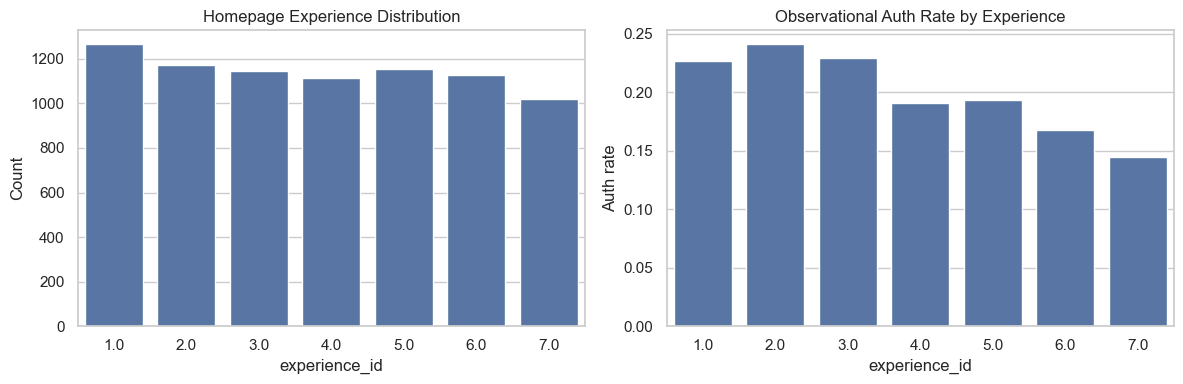

Events per session (summary):


,count,mean,std,min,25%,50%,75%,max
0,23671.0,5.371129,7.195803,1.0,1.0,1.0,8.0,28.0


Unique cookie IDs: 850


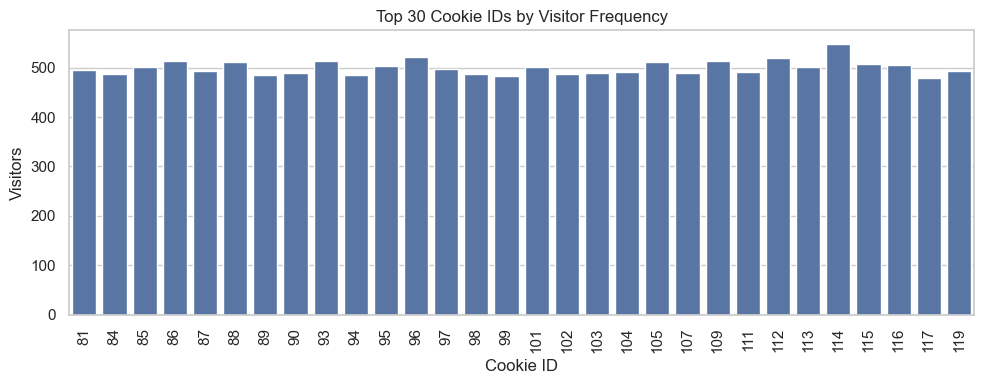

,url,count
0,/,18050
1,/free-edition,7219
2,/pricing,7119
3,/personal-taxes,6729
4,/premier,6357
5,/deluxe,6133
6,/blog/tax-tips,6008
7,/sign-in,5724
8,/expert-review,5718
9,/create-account,5700


,action,count
0,scroll,21335
1,click_cta,17776
2,click_nav,14279
3,view_homepage,8000
4,expand_faq,5969
5,submit_form,4804
6,open_modal,4793
7,play_video,4773
8,hover,3535


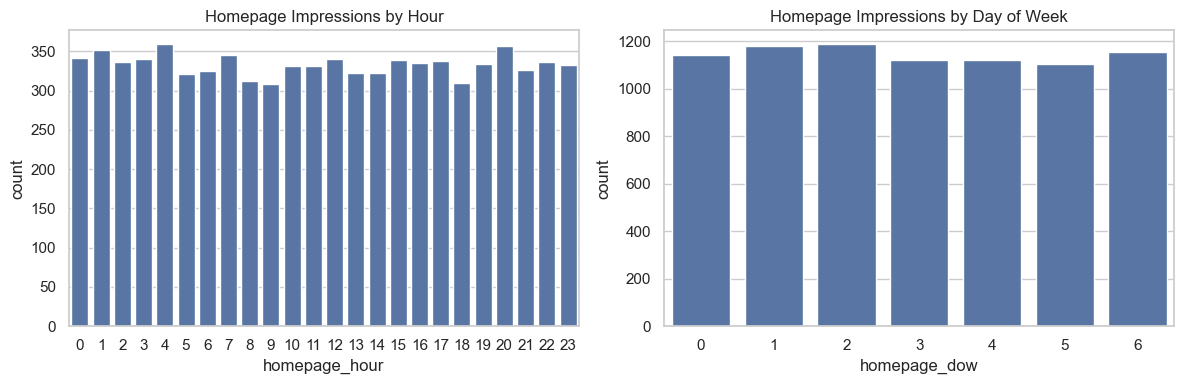

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_experience_distribution(decision_df, ax=axes[0])
plot_auth_rate_by_experience(decision_df, ax=axes[1])
plt.tight_layout()
plt.show()

print("Events per session (summary):")
display(events_per_session(activity_df).describe().to_frame().T)

cookie_counts = cookie_id_counts(activity_df)
print(f"Unique cookie IDs: {len(cookie_counts)}")
plot_cookie_frequency(cookie_counts)
plt.show()

display(value_counts_table(activity_df["url"], "url"))
display(value_counts_table(activity_df["action"], "action"))

plot_homepage_time_patterns(decision_df)
plt.show()

## Section 3 — Label Construction

Clickstream loaded in Section 1 is already truncated to events **strictly before** each visitor's first auth. `authenticated = 1` only when first auth occurs in the **same `visitor_session_id`** as the homepage impression, at or after the homepage timestamp.

In [4]:
print(f"Decision points: {len(decision_df):,}")
print(f"Auth rate: {decision_df['authenticated'].mean():.1%}")
display(decision_df.head())
display(auth_rate_by_experience(decision_df).to_frame("auth_rate"))

Decision points: 8,000
Auth rate: 20.1%


,visitor_identifier,visitor_session_id,cookie_ids,homepage_dt,homepage_event_ts,experience_id_shown,authenticated,homepage_hour,homepage_dow
0,vis_000001,vis_000001_sess_05,"[355, 357, 363, 373, 376, 407, 412, 418, 419, ...",2024-03-26 03:47:08+00:00,1711424828,4.0,0,3,1
1,vis_000002,vis_000002_sess_05,"[3, 11, 13, 19, 20, 29, 37, 41, 42, 44, 46, 54...",2024-01-26 07:46:08+00:00,1706255168,1.0,0,7,4
2,vis_000003,vis_000003_sess_01,"[463, 467, 474, 478, 484, 486, 489, 492, 495, ...",2024-01-17 05:26:44+00:00,1705469204,6.0,0,5,2
3,vis_000004,vis_000004_sess_03,"[262, 289, 329, 335, 362, 378, 386, 389, 396, ...",2024-02-05 09:34:57+00:00,1707125697,2.0,0,9,0
4,vis_000005,vis_000005_sess_04,"[346, 355, 357, 363, 364, 370, 376, 413, 420, ...",2024-01-04 09:55:05+00:00,1704362105,1.0,0,9,3


,auth_rate
experience_id_shown,
1.0,0.226877
2.0,0.240820
3.0,0.229021
4.0,0.191031
5.0,0.193241
6.0,0.167405
7.0,0.144814


### Visitor-level exposure (converted vs not)

Comparisons use **one row per visitor**: converted = ever authenticated in-session at a homepage decision (`authenticated.max()`). Experiences = distinct `experience_id` seen on homepage impressions; sessions = distinct `visitor_session_id` in the truncated (pre-auth) clickstream.

n_experiences_seen            n_sessions           
                              mean median max       mean median max
converted_label                                                    
Converted                      1.0    1.0   1       2.97    3.0   5
Not converted                  1.0    1.0   1       2.96    3.0   5

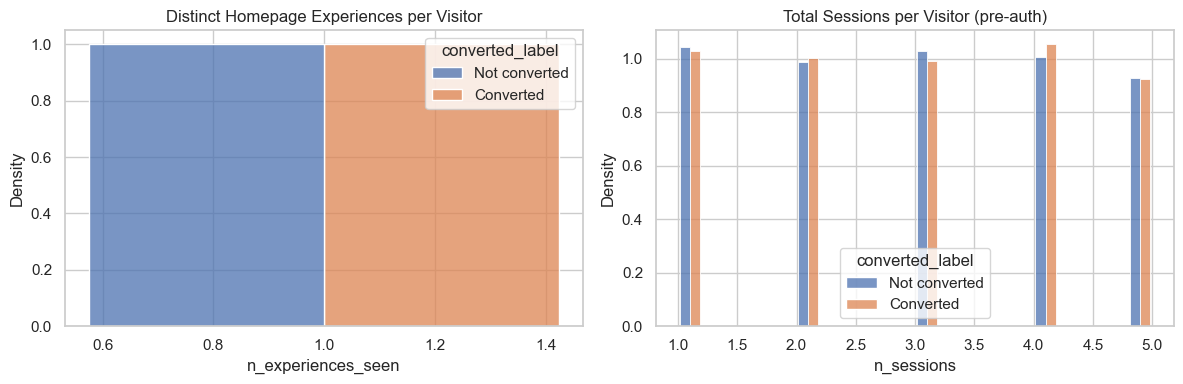

In [5]:
visitor_df = build_visitor_eda_frame(decision_df, activity_df)
display(visitor_metric_summary_by_conversion(visitor_df))
plot_visitor_conversion_distributions(decision_df, activity_df)
plt.show()

## Section 4 — Feature Engineering (per session)

All **57** model inputs are computed from clickstream **strictly before** the homepage timestamp on that row (no post-homepage or post-auth leakage). `experience_id_shown` is the treatment variable in the model and is not included in the 57 inputs below.

Cookie frequent/vocab/top-hit ID sets are fit on **train visitors only** and applied to validation.

| Group | Count | What events are used |
|-------|------:|----------------------|
| A. Session aggregates | 4 | All pre-homepage events for this visitor |
| B. Recency & time-of-day | 4 | Visitor history + homepage timestamp |
| C. Temporal windows | 4 | All pre-homepage events for this visitor |
| D. Visitor URL buckets | 4 | All pre-homepage URLs for this visitor |
| E. Current-session volume | 4 | Pre-homepage events in the homepage session only |
| F. Session action counts | 6 | Pre-homepage events in the homepage session only |
| G. Session URL prefix flags | 8 | Pre-homepage URLs in the homepage session only |
| H. Session URL buckets | 4 | Pre-homepage URLs in the homepage session only |
| I. Intent proxies | 4 | Mix of visitor-wide and current-session signals |
| J. Cookie summaries | 15 | `cookie_ids` on the homepage decision row |
| **Total** | **57** | |

---

### A. Session aggregates (4) — returning vs first-time visitors

| Feature | Definition | Why it matters |
|---------|------------|----------------|
| `num_sessions` | Count of distinct `visitor_session_id` with any event before homepage | Repeat visitors often have higher intent and different response to homepage creative |
| `session_duration_avg` | Mean (max − min event time) per session, averaged across sessions | Long sessions may indicate deep research or friction before converting |
| `pages_per_session` | Mean number of unique URLs per session | Breadth of exploration per visit |
| `actions_per_session` | Mean number of clickstream events per session | Overall engagement intensity across visits |

---

### B. Recency & time-of-day (4) — how “fresh” the visit is

| Feature | Definition | Why it matters |
|---------|------------|----------------|
| `time_since_last_visit_hours` | Hours between the visitor’s last pre-homepage event and the homepage | Short gaps suggest an active in-flight journey; long gaps suggest a cold return |
| `days_since_first_seen` | Days from the visitor’s first recorded event to homepage | Captures visitor maturity (new vs established on site) |
| `homepage_hour` | Hour of day (0–23) of the homepage impression | Auth and engagement vary by time of day |
| `homepage_dow` | Day of week (0=Monday … 6=Sunday) of the homepage impression | Weekly seasonality in tax-season traffic |

---

### C. Temporal windows (4) — short-horizon activity bursts

| Feature | Definition | Why it matters |
|---------|------------|----------------|
| `events_last_5min` | Event count in the 5 minutes before homepage | Detects a late burst of clicks right before the homepage (high intent or indecision) |
| `sessions_last_7days` | Distinct sessions with any event in the 7 days before homepage | Recent return frequency without using full lifetime history |
| `distinct_urls` | Unique URLs touched before homepage (visitor-wide) | Overall breadth of site exploration |
| `distinct_actions` | Unique `action` values before homepage (visitor-wide) | Diversity of interaction types (scroll vs CTA vs form, etc.) |

---

### D. Visitor URL buckets (4) — lifetime path themes (regex, any-hit)

Each flag is **1** if **any** pre-homepage URL matches the bucket pattern (see `URL_BUCKETS` in `src/config.py`).

| Feature | Definition | Why it matters |
|---------|------------|----------------|
| `url_bucket_product_page` | Hit product/edition URLs (e.g. personal-taxes, deluxe, compare/products) | Product research before seeing the homepage |
| `url_bucket_pricing_page` | Hit pricing / free-edition / compare URLs | Price sensitivity or plan comparison |
| `url_bucket_help_page` | Hit help / support / expert URLs | Possible confusion, support need, or high assistance intent |
| `url_bucket_checkout_page` | Hit sign-in / create-account URLs | Already near account creation before homepage |

---

### E. Current-session volume (4) — this visit only, before homepage

| Feature | Definition | Why it matters |
|---------|------------|----------------|
| `n_session_events` | Number of events in the homepage session before the homepage row | How much the visitor did in the same visit before the impression |
| `n_unique_urls_session` | Unique URLs in that session before homepage | Depth of navigation in the current visit |
| `n_unique_actions_session` | Unique action types in that session before homepage | Variety of behaviors in the current visit |
| `seconds_since_session_start` | Seconds from first event in this session to homepage | Early vs late homepage within the session |

---

### F. Session action counts (6) — engagement mix this session

Raw counts (not binary) of each `action` in the homepage session before homepage.

| Feature | Definition | Why it matters |
|---------|------------|----------------|
| `session_action_click_cta` | Count of `click_cta` | Primary conversion-oriented clicks |
| `session_action_play_video` | Count of `play_video` | Content engagement |
| `session_action_scroll` | Count of `scroll` | Passive browsing / page depth |
| `session_action_expand_faq` | Count of `expand_faq` | Information seeking |
| `session_action_submit_form` | Count of `submit_form` | Form completion attempts |
| `session_action_click_nav` | Count of `click_nav` | General navigation |

---

### G. Session URL prefix flags (8) — specific paths this session

Each flag is **1** if **any** pre-homepage URL in the **current session** contains the path prefix (substring match).

| Feature | Definition | Why it matters |
|---------|------------|----------------|
| `session_url_contains_pricing` | URL contains `pricing` | Price page in current visit |
| `session_url_contains_help` | URL contains `help` | Help content in current visit |
| `session_url_contains_blog` | URL contains `blog` | Content marketing touch |
| `session_url_contains_tools` | URL contains `tools` | Calculator / tool usage |
| `session_url_contains_sign_in` | URL contains `sign-in` | Login path in current visit |
| `session_url_contains_create_account` | URL contains `create-account` | Registration path in current visit |
| `session_url_contains_business` | URL contains `business` | Business SKU interest |
| `session_url_contains_mobile` | URL contains `mobile` | Mobile-specific flows |

---

### H. Session URL buckets (4) — same themes as (D), session-scoped

Same regex buckets as section D, but evaluated only on URLs from the **homepage session** before homepage. Separates “ever looked at pricing” (D) from “looked at pricing **this visit**” (H).

| Feature | Definition | Why it matters |
|---------|------------|----------------|
| `session_url_bucket_product_page` | Product bucket hit in current session | Immediate product intent |
| `session_url_bucket_pricing_page` | Pricing bucket hit in current session | Immediate price comparison |
| `session_url_bucket_help_page` | Help bucket hit in current session | Friction or support in this visit |
| `session_url_bucket_checkout_page` | Checkout bucket hit in current session | Near-login behavior in this visit |

---

### I. Intent proxies (4) — behavioral shortcuts

| Feature | Definition | Why it matters |
|---------|------------|----------------|
| `viewed_help_content` | Visitor-wide help bucket hit (same pattern as `url_bucket_help_page`) | Site-wide support/friction signal |
| `visited_pricing` | Visitor-wide pricing bucket hit | Site-wide price sensitivity |
| `repeated_same_page` | Max count of the same URL within the current session (before homepage) | Hesitation or stuck behavior on one page |
| `started_tax_flow` | Visitor-wide hit on tax-flow pattern (sign-in, create-account, product paths) | High-intent funnel entry before homepage |

---

### J. Cookie summaries (15) — compact identity/history signals

Built from the homepage row’s `cookie_ids` JSON array. We avoid one-hot encoding hundreds of IDs; instead we summarize **how many** and **how common** those IDs are vs train vocabulary.

| Feature | Definition | Why it matters |
|---------|------------|----------------|
| `has_cookies` | 1 if the visitor has at least one cookie ID on the row | Distinguishes empty vs attributed visitors |
| `n_cookies` | Count of distinct cookie IDs | Breadth of stored client-side attributes |
| `n_frequent_cookies` | How many of the visitor’s IDs appear in the train **top-10** global cookie set | Exposure to common tracking segments |
| `n_rare_cookies` | IDs not in that top-10 set | Long-tail / niche attribute combinations |
| `frequent_cookie_share` | `n_frequent_cookies / n_cookies` (0 if no cookies) | Share of cookie bag that is “mainstream” |
| `n_in_vocab_cookies` | IDs in train **top-50** vocab | Coverage of modeled cookie space |
| `n_out_of_vocab_cookies` | IDs outside top-50 | Novel or tail cookies not in vocab |
| `in_vocab_share` | `n_in_vocab_cookies / n_cookies` | How much of the bag is vocab-covered |
| `any_frequent_cookie` | 1 if `n_frequent_cookies > 0` | Quick flag for any mainstream cookie |
| `any_rare_cookie` | 1 if `n_rare_cookies > 0` | Quick flag for any tail cookie |
| `n_global_top_cookie_hits` | Count of train global **top-3** cookie IDs present | Concentration on the most common IDs |
| `log1p_n_cookies` | `log(1 + n_cookies)` | Stabilizes scale when cookie count is heavy-tailed |
| `has_global_top_cookie_1` | 1 if train rank-#1 cookie ID is present | Strongest single cookie segment hit |
| `has_global_top_cookie_2` | 1 if train rank-#2 cookie ID is present | Second global segment hit |
| `has_global_top_cookie_3` | 1 if train rank-#3 cookie ID is present | Third global segment hit |

In [6]:
from src.dataset import build_decision_dataset, get_feature_columns, split_visitors
from src.features import feature_group_counts, summarize_feature_groups

train_visitors, val_visitors = split_visitors(decision_df)
dataset = build_decision_dataset(
    decision_df, activity_df, train_visitor_ids=train_visitors
)
feature_cols = get_feature_columns(dataset)

print(f"Dataset shape: {dataset.shape}")
print(f"Feature columns: {len(feature_cols)} (documented total: 57)")
display(summarize_feature_groups(feature_cols))
assert sum(feature_group_counts(feature_cols).values()) == len(feature_cols)

from src.features import COOKIE_FEATURE_NAMES

non_cookie_cols = [c for c in feature_cols if c not in COOKIE_FEATURE_NAMES]
print(f"Non-cookie features: {len(non_cookie_cols)}")
display(dataset[non_cookie_cols].head())
display(dataset[list(COOKIE_FEATURE_NAMES)].head())

Dataset shape: (8000, 62)
Feature columns: 57 (documented total: 57)


,group,feature_count
0,session_agg,4
1,recency,4
2,temporal,4
3,visitor_url_bucket,4
4,session_volume,4
5,session_action,6
6,session_url_prefix,8
7,session_url_bucket,4
8,intent,4
9,cookie,15


Non-cookie features: 42


,num_sessions,session_duration_avg,pages_per_session,actions_per_session,time_since_last_visit_hours,days_since_first_seen,homepage_hour,homepage_dow,events_last_5min,sessions_last_7days,distinct_urls,distinct_actions,url_bucket_product_page,url_bucket_pricing_page,url_bucket_help_page,...,session_url_contains_help,session_url_contains_blog,session_url_contains_tools,session_url_contains_sign_in,session_url_contains_create_account,session_url_contains_business,session_url_contains_mobile,session_url_bucket_product_page,session_url_bucket_pricing_page,session_url_bucket_help_page,session_url_bucket_checkout_page,viewed_help_content,visited_pricing,repeated_same_page,started_tax_flow
0,5,38896.20,2.800000,3.800000,0.266667,3.455764,3,1,0,5,13,5,1,1,1,...,0,0,1,0,1,1,0,1,1,1,1,1,1,2,1
1,5,42602.60,3.000000,4.000000,0.233333,2.908600,7,4,0,5,14,5,1,1,1,...,1,1,1,1,1,1,0,1,0,1,1,1,1,2,1
2,1,276250.00,11.000000,12.000000,0.083333,3.200810,5,2,1,1,11,2,1,1,1,...,0,1,1,0,0,1,1,1,1,1,0,1,1,2,1
3,3,17994.00,6.333333,8.666667,0.433333,0.694734,9,0,0,3,16,6,1,1,1,...,1,0,1,1,1,1,1,1,1,1,1,1,1,4,1
4,4,27859.75,2.750000,3.500000,0.433333,2.401840,9,3,0,4,11,4,1,1,1,...,0,1,0,0,0,1,0,1,1,0,0,1,1,4,1


,has_cookies,n_cookies,n_frequent_cookies,n_rare_cookies,frequent_cookie_share,n_in_vocab_cookies,n_out_of_vocab_cookies,in_vocab_share,any_frequent_cookie,any_rare_cookie,n_global_top_cookie_hits,log1p_n_cookies,has_global_top_cookie_1,has_global_top_cookie_2,has_global_top_cookie_3
0,1,32,0,32,0.000000,0,32,0.000000,0,1,0,3.496508,0,0,0
1,1,27,4,23,0.148148,8,19,0.296296,1,1,1,3.332205,0,1,0
2,1,39,0,39,0.000000,1,38,0.025641,0,1,0,3.688879,0,0,0
3,1,18,0,18,0.000000,0,18,0.000000,0,1,0,2.944439,0,0,0
4,1,37,0,37,0.000000,1,36,0.027027,0,1,0,3.637586,0,0,0


## Section 5 — Train / Validation Split

Visitor-level 80/20 split stratified on `authenticated` to prevent leakage across splits.

In [7]:
train_df = dataset[dataset["visitor_identifier"].isin(train_visitors)].reset_index(drop=True)
val_df = dataset[dataset["visitor_identifier"].isin(val_visitors)].reset_index(drop=True)

print(f"Train: {len(train_df):,} sessions ({train_df['authenticated'].mean():.1%} auth)")
print(f"Val:   {len(val_df):,} sessions ({val_df['authenticated'].mean():.1%} auth)")

Train: 6,400 sessions (20.0% auth)
Val:   1,600 sessions (20.1% auth)


## Section 6 — Model Training (Logistic Regression)

Single LR model: `P(auth | features, experience_id)` with balanced class weights.

In [8]:
from src.evaluation import evaluate_model, plot_calibration
from src.modeling import train_auth_model

auth_model = train_auth_model(train_df, feature_cols)

train_metrics = evaluate_model(auth_model, train_df, "train")
val_metrics = evaluate_model(auth_model, val_df, "validation")
display(pd.concat([train_metrics, val_metrics], axis=1))

,train,validation
roc_auc,0.579447,0.555365
pr_auc,0.230564,0.217804
log_loss,0.683194,0.689736
brier_score,0.245162,0.248420
auth_rate,0.200469,0.200625
mean_predicted_prob,0.493623,0.496193


## Section 7 — Evaluation

,experience_id_shown,auth_rate,count
0,1.0,0.224638,276
1,2.0,0.239837,246
2,3.0,0.260274,219
3,4.0,0.198020,202
4,5.0,0.169565,230
5,6.0,0.129187,209
6,7.0,0.169725,218


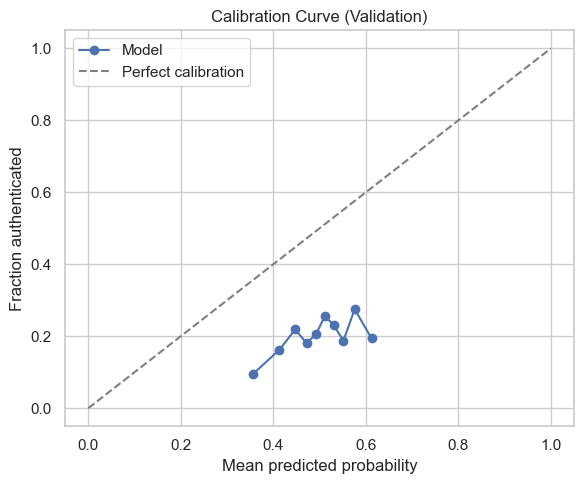

In [9]:
from src.evaluation import observational_auth_by_experience, policy_comparison
from src.modeling import predict_proba

display(observational_auth_by_experience(val_df))

y_val = val_df["authenticated"].values
p_val = predict_proba(auth_model, val_df)
plot_calibration(y_val, p_val)
plt.show()

## Section 8 — Counterfactual Uplift & Recommendations

For each validation session:
1. Score all 7 experiences
2. Recommend `argmax P(auth | X, k)`
3. Uplift = `p_best - p_shown`

,value
n_sessions,1600.000000
pct_positive_uplift,0.846250
mean_uplift,0.066238
median_uplift,0.075774
pct_changed_experience,0.846250
mean_p_shown,0.496193
mean_p_best,0.562430


,policy,auth_rate
0,historical_actual,0.200625
1,historical_model_pred,0.496193
2,recommended_model_est,0.562430


,visitor_session_id,experience_id_shown,recommended_experience,p_shown,p_best,predicted_uplift,authenticated
0,vis_000004_sess_03,2.0,2,0.540494,0.540494,0.000000,0
1,vis_000005_sess_04,1.0,2,0.583352,0.590529,0.007177,0
2,vis_000006_sess_03,3.0,2,0.492729,0.530575,0.037847,0
3,vis_000011_sess_03,6.0,2,0.427556,0.536287,0.108731,0
4,vis_000016_sess_05,3.0,2,0.524716,0.562296,0.037580,1
5,vis_000018_sess_04,6.0,2,0.493872,0.601740,0.107868,1
6,vis_000020_sess_05,2.0,2,0.486642,0.486642,0.000000,0
7,vis_000045_sess_01,2.0,2,0.579929,0.579929,0.000000,0
8,vis_000063_sess_03,6.0,2,0.537556,0.642846,0.105290,1
9,vis_000065_sess_04,3.0,2,0.570307,0.606983,0.036675,1


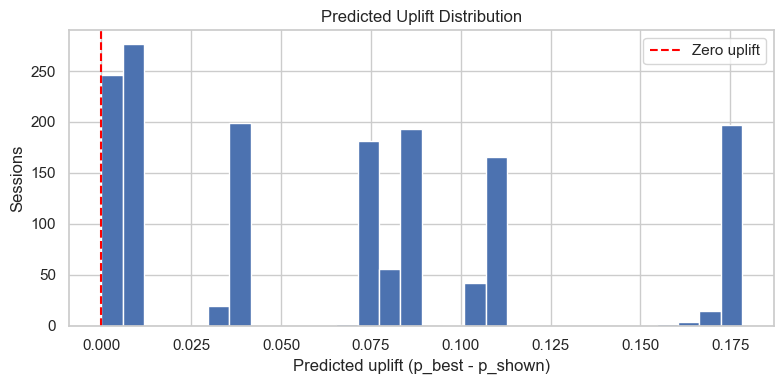

In [10]:
from src.evaluation import plot_uplift_distribution
from src.uplift import recommend_experiences, uplift_summary

val_features = val_df[feature_cols]
recommendations = recommend_experiences(auth_model, val_features, val_df)

display(uplift_summary(recommendations).to_frame("value"))
display(policy_comparison(recommendations))

display(
    recommendations[
        ["visitor_session_id", "experience_id_shown", "recommended_experience",
         "p_shown", "p_best", "predicted_uplift", "authenticated"]
    ].head(10)
)

plot_uplift_distribution(recommendations)
plt.show()

## Section 9 — Summary & Production Notes

### Key takeaways
- Built **six categories** of session-level features (session agg, recency, cookies, URL buckets, intent, temporal windows) from raw clickstream
- Used top-K cookie encoding instead of naive 850-dimension one-hot; documented FeatureHasher as production scale-up
- Trained logistic regression with experience as treatment variable
- Generated per-session counterfactual scores and uplift vs. shown experience

### Production deployment sketch
1. **Real-time feature pipeline:** aggregate session events on each homepage request
2. **Score 7 experiences:** batch counterfactual inference
3. **Serve argmax:** show recommended experience
4. **Log:** features, all 7 probabilities, chosen experience, propensity of shown experience (for offline DR eval)
5. **Validate online:** randomized holdout or interleaving experiment

### What we would do with more time
- `FeatureHasher` / TF-IDF for cookies at scale
- Propensity-weighted offline policy evaluation
- Non-linear models (GBM) with cookie interactions
- Segment-level uplift analysis and fairness checks

See **Section 10** for a full treatment of rigorous offline causal inference (propensity models, doubly robust OPE, uplift learners, and validation strategy).

## Section 10 — Rigorous Offline Causal Inference (Appendix)

Section 8 scores counterfactuals with a single outcome model (S-learner) and reports `predicted_uplift = p_best - p_shown`. That is useful for exploration, but it is **not** a validated causal uplift estimate. With offline logs only, we never observe what would have happened under a different experience — so we must separate **model scores** from **causal estimates** and use methods that correct for how experiences were assigned.

### What Section 8 actually computes

| Quantity | What it is | Causal? |
|----------|------------|---------|
| `p_best - p_shown` | Counterfactual contrast from one LR | No — extrapolation |
| `mean(predicted_uplift)` | Average model score | No |
| `mean(p_best)` in `policy_comparison` | Direct-method policy value from same model | No — optimistically biased |
| Actual auth rate under shown experience | Observational outcome | Yes for **logging policy only** |

These answer: *"If our outcome model extrapolates correctly, how much better could we do?"* That is a hypothesis, not proof.

### Causal estimands (pick one primary question)

| Estimand | Definition | Use when |
|----------|------------|----------|
| **ATE** | E[Y(a) − Y(a₀)] averaged over all visitors | Comparing one arm to a control |
| **CATE / uplift** | τ(x) = E[Y(a) − Y(a₀) \| X = x] | Personalization / heterogeneous effects |
| **Policy value V(π)** | E[Y under π(x)] where π(x) = recommended arm | Evaluating a recommender before launch |

Section 8 implicitly targets **CATE** (per-session contrast) and **V(π)** (argmax policy), but estimates neither with a causal estimator.

### Identification assumptions (must be stated and checked)

1. **Unconfoundedness** — assignment independent of potential outcomes given X: (Y(1),…,Y(7)) ⊥ A \| X. Weak on real observational logs; partially violated even in synthetic data (~15% of assignments use segment-best experience).
2. **Overlap / positivity** — P(A = a \| X) > 0 for every arm a you might recommend. Without overlap, counterfactuals are pure extrapolation.
3. **SUTVA** — no interference; one experience per session; stable treatment definition.
4. **Correct logging** — propensity of the served arm is known or estimable from the logging policy.

If (1) fails, no amount of modeling fixes it without stronger data (randomization, instruments, or sensitivity bounds).

### Two-model framework

Rigorous offline work fits **two** models on pre-homepage features X:

| Model | Target | Typical approach |
|-------|--------|------------------|
| **Propensity** π(a \| x) | P(experience shown = a \| X) | Multinomial logistic or GBM |
| **Outcome** μ_a(x) | E[Y \| X, A = a] | T-learner, X-learner, or calibrated GBM per arm |

**S-learner** (what we use now): one model with treatment as a feature. Simple, but poor extrapolation to rare arms.

**T-learner**: separate μ_a per arm on rows where A = a. Often better for uplift.

**X-learner**: stage-1 T-learners + propensity-weighted pseudo-outcomes in stage 2. Helps with arm imbalance.

**R-learner / DR-learner**: targets τ(x) directly; strong for policy learning.

For 7 arms: multinomial propensity + per-arm outcome models + overlap diagnostics per arm.

### Offline policy evaluation (OPE)

To estimate how a **new policy π** would perform, use estimators that reweight observational data — not `mean(p_best)`.

**Inverse propensity scoring (IPS):**

$$\hat V_{\text{IPS}}(\pi) = \frac{1}{n}\sum_i \frac{\mathbb{1}[A_i = \pi(x_i)]}{\hat\pi(A_i \mid x_i)} \, Y_i$$

Unbiased if π is correct; high variance when propensities are small. Use **SNIPS** (self-normalized IPS) for stability.

**Direct method (DM):**

$$\hat V_{\text{DM}}(\pi) = \frac{1}{n}\sum_i \mu_{\pi(x_i)}(x_i)$$

What `policy_comparison` approximates — but biased if μ is misspecified.

**Doubly robust (DR)** — the standard workhorse:

$$\hat V_{\text{DR}}(\pi) = \frac{1}{n}\sum_i \left[ \mu_{\pi(x_i)}(x_i) + \frac{\mathbb{1}[A_i = \pi(x_i)]}{\hat\pi(A_i \mid x_i)} \big(Y_i - \mu_{A_i}(x_i)\big) \right]$$

Consistent if **either** propensity **or** outcome model is correct. Use **cross-fitting** (fit on folds, evaluate on held-out fold) to avoid optimistic bias. Clip extreme weights or use switch-DR when overlap is thin.

Compare at minimum:
- **Logging policy** π₀ (what was shown) — DR estimate should match observational auth rate when well specified
- **Candidate policy** π (argmax recommender from Section 8)
- **Uniform random** baseline (especially on synthetic data where ~85% of assignments are random)

Report **bootstrap confidence intervals** on V_DR(π), not just point estimates.

### Offline validation (what you can still do without an A/B test)

| Check | Purpose |
|-------|---------|
| Overlap / propensity histograms | Flag arms with π(a \| x) ≈ 0 in regions where π recommends them |
| Balance on X after IPW | Weighted standardized mean differences |
| Outcome model calibration | Reliability on observed (X, A, Y) — Section 7 calibration plot |
| Unconfounded subset | On synthetic data, evaluate only the ~85% randomly assigned sessions |
| Sensitivity analysis | E-values / Rosenbaum bounds for unmeasured confounding |
| Oracle check (synthetic only) | Compare estimated rankings to hidden segment → best experience in `generate_dataset.py` |
| Stability | Bootstrap CIs; IPS vs DR agreement |

You **cannot** directly calibrate counterfactual uplift on real data without randomization. Uplift curves (Qini) only make sense with a proxy ground truth.

### Recommended workflow

```
Pre-homepage features X
        │
        ├─► Propensity model π(a|x) ──► Overlap diagnostics
        │
        └─► Outcome models μ_a(x) ──► Counterfactual scores
                    │
                    ▼
        Cross-fitted DR / SNIPS policy evaluation
                    │
                    ▼
        DR stable & CI excludes 0? ──No──► Revise features, restrict policy, improve logging
                    │
                   Yes
                    ▼
        Online RCT or holdout experiment
```

### Production logging requirements

To make offline causal work possible later, log on every homepage impression:
- Pre-homepage feature vector (or hash)
- All 7 counterfactual scores (optional but useful)
- **Propensity π₀(a \| x)** of the experience actually served
- Chosen experience and outcome (auth)

Without logged propensities, DR collapses to outcome modeling — the current Section 8 approach.

### Concrete next steps for this codebase

1. ~~Add `src/ope.py` with cross-fitted multinomial propensity + DR policy evaluation~~ **Done — see cells below**
2. Replace or supplement S-learner with T-learner / X-learner outcome models
3. Add overlap-aware policy: recommend arm a only where π(a | x) > ε
4. ~~Wire DR comparison (logging vs recommended vs random) into the notebook~~ **Done — see cells below**
5. On synthetic data, validate on the random-assignment subset and against the hidden segment oracle
6. Close the loop with an online experiment before trusting revenue impact

### Bottom line

Section 8 is a reasonable **first-pass personalization prototype**. A rigorous offline uplift study adds explicit estimands, propensity correction, doubly robust OPE with uncertainty, dedicated uplift learners, sensitivity analysis, and online validation. Treat `predicted_uplift` as a ranking signal until DR/OPE supports it.

### Implementation — Offline policy evaluation

Fit propensity π(a|x) on **train**, score counterfactual outcomes μ_a(x) with the Section 6 auth model, and evaluate on **validation** with DM, IPS, SNIPS, and doubly robust (DR) estimators. Propensities are clipped from below (default 0.05) and row-renormalized to limit extreme importance weights.

,dm_auth_rate,ips_auth_rate,snips_auth_rate,dr_auth_rate,dr_ci_lower,dr_ci_upper,pct_policy_matches_logging,actual_auth_rate
policy,,,,,,,,
logging,0.4962,1.3332,0.1828,-1.7680,-1.9299,-1.6212,1.0000,0.2006
recommended,0.5624,0.2556,0.2258,0.1931,0.1225,0.2640,0.1538,NaN
uniform_random,0.4923,NaN,NaN,-1.7719,-1.9359,-1.6245,NaN,NaN


,experience_id,n_sessions,mean_propensity,min_propensity,pct_below_0.05,pct_below_0.10,overall_prop_treated_mean,overall_prop_treated_min
0,1,276,0.168660,0.076431,0.000000,0.079710,0.149153,0.049468
1,2,246,0.149530,0.069090,0.000000,0.134146,0.149153,0.049468
2,3,219,0.150299,0.055405,0.000000,0.068493,0.149153,0.049468
3,4,202,0.145156,0.079117,0.000000,0.059406,0.149153,0.049468
4,5,230,0.146489,0.070568,0.000000,0.100000,0.149153,0.049468
5,6,209,0.146840,0.049468,0.004785,0.110048,0.149153,0.049468
6,7,218,0.131611,0.062949,0.000000,0.229358,0.149153,0.049468


Observational auth rate (validation): 0.2006
Compare logging-policy DR/SNIPS to observational rate; compare recommended vs logging DR with overlapping CIs.


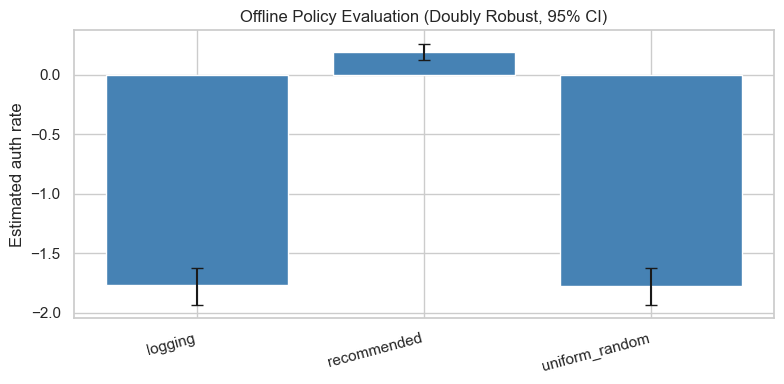

In [ ]:
from src.evaluation import plot_policy_ope
from src.ope import compare_policies_holdout, overlap_diagnostics

ope_policies = {
    "logging": val_df["experience_id_shown"].values,
    "recommended": recommendations["recommended_experience"].values,
}

ope_results, prop_matrix, outcome_matrix = compare_policies_holdout(
    train_df,
    val_df,
    feature_cols,
    ope_policies,
    auth_model=auth_model,
    n_bootstrap=500,
)

display(ope_results.round(4))
display(overlap_diagnostics(prop_matrix, val_df["experience_id_shown"].values))

obs_auth_rate = val_df["authenticated"].mean()
print(f"Observational auth rate (validation): {obs_auth_rate:.4f}")
print(
    "Compare logging-policy DR/SNIPS to observational rate; "
    "compare recommended vs logging DR with overlapping CIs."
)

plot_policy_ope(ope_results)
plt.show()

**How to read these results**

- **Logging + SNIPS** should track the observational validation auth rate when propensities are reasonable; use it as a sanity check.
- **Logging + DR** requires a well-calibrated outcome model *or* a correct propensity model. If `mean_predicted_prob` from Section 6 is far above `auth_rate`, DR for the logging policy can be unstable — prefer SNIPS for the baseline in that case.
- **Recommended + DR** estimates counterfactual policy value with bias correction; compare its CI to logging SNIPS/DR for a conservative offline lift read.
- **DM** (`dm_auth_rate`) is the direct-method estimate from the same outcome model as Section 8 — optimistic when the model overpredicts.